# Final Dataset Construction

This notebook combines all engineered features produced during the data preparation phase.

Sources:
- listings_features.csv
- review_features.csv

The resulting dataset will be used for machine learning models such as Decision Trees and Random Forests.

In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

Project root: /Users/andrerozza/Data Science for Business/airbnb-rome-analysis


## 1. Load Engineered Datasets

The datasets generated in Notebook 02 and Notebook 03 are loaded and prepared for integration.

- listings_features.csv
- review_features.csv

In [31]:
listings_features = pd.read_csv(
    "../data/listings_features.csv"
)

review_features = pd.read_csv(
    "../data/review_features.csv"
)
seasonality_features = pd.read_csv(
    "../data/seasonality_features.csv"
    )

FileNotFoundError: [Errno 2] No such file or directory: '../data/seasonality_features.csv'

## 2. Dataset Inspection

Before merging the datasets, we verify their dimensions, structure, and merge keys.

In [ ]:
print(listings_features.shape)
print(review_features.shape)

(34324, 64)
(32826, 9)


In [ ]:
listings_features.head()

,id,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,...,neighbourhood_cleansed_VII San Giovanni/Cinecittà,neighbourhood_cleansed_VIII Appia Antica,neighbourhood_cleansed_X Ostia/Acilia,neighbourhood_cleansed_XI Arvalia/Portuense,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia,distance_to_colosseum,location_cluster
0,2737,59.52,41.87136,12.48215,1,1.0,1.0,1.5,0,NaN,...,0,1,0,0,0,0,0,0,2.252726,2.0
1,12398,117.13,41.92582,12.46928,3,2.0,3.0,1.0,1,NaN,...,0,0,0,0,0,0,0,0,4.389669,0.0
2,19965,160.60,41.90823,12.45293,5,2.0,3.0,1.0,0,NaN,...,0,0,0,0,0,0,0,0,3.824847,0.0
3,20534,243.67,41.88992,12.46823,4,1.0,3.0,1.0,1,NaN,...,0,0,0,0,0,0,0,0,1.989591,2.0
4,20587,302.50,41.88992,12.46823,4,2.0,4.0,1.0,1,NaN,...,0,0,0,0,0,0,0,0,1.989591,2.0


In [ ]:
review_features.head()

,listing_id,review_count,avg_review_length,avg_sentiment_score,sentiment_label,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review
0,2737,5,51.800000,0.956560,positive,2015,5,8,4077
1,11834,302,74.165563,0.849785,positive,2026,6,7,29
2,12398,85,84.658824,0.719140,positive,2025,8,1,339
3,19965,195,44.953846,0.463973,positive,2026,6,13,23
4,20534,50,60.200000,0.730592,positive,2022,11,22,1322


In [ ]:
seasonality_features.head()

,Month_num,Seasonality_Index,season,month_sin,month_cos
0,1,0.000000,Winter,0.500000,8.660254e-01
1,2,0.104247,Winter,0.866025,5.000000e-01
2,3,0.395881,Spring,1.000000,6.123234e-17
3,4,0.692730,Spring,0.866025,-5.000000e-01
4,5,0.906591,Spring,0.500000,-8.660254e-01


In [ ]:
print(review_features.columns.tolist())

['listing_id', 'review_count', 'avg_review_length', 'avg_sentiment_score', 'sentiment_label', 'latest_review_year', 'latest_review_month', 'latest_review_day', 'days_since_latest_review']


### 2.1 Verify Merge Keys

The listings dataset uses the variable id as its primary identifier, while the review dataset uses listing_id.

We verify that both identifiers exist before performing the merge operation.

In [ ]:
print("id" in listings_features.columns)
print("listing_id" in review_features.columns)

True
True


## 3. Merge Listings and Review Features

Review-derived variables are merged with the listings dataset using the Airbnb listing identifier.

A left join is used so that all listings remain in the final dataset, even if some properties have never received reviews.

In [ ]:
final_df = listings_features.merge(
    review_features,
    left_on="id",
    right_on="listing_id",
    how="left"
)

#deletion of duplicate key
final_df.drop(
    columns=["listing_id"],
    inplace=True
)

In [ ]:
month_key = final_df["latest_review_month"].replace(-1, np.nan)

final_df = final_df.merge(
    seasonality_features,
    left_on=month_key,
    right_on="Month_num",
    how="left",
).drop(columns=["Month_num"])

In [ ]:
final_df.head()

,id,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,...,avg_sentiment_score,sentiment_label,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review,Seasonality_Index,season,month_sin,month_cos
0,2737,59.52,41.87136,12.48215,1,1.0,1.0,1.5,0,NaN,...,0.956560,positive,2015.0,5.0,8.0,4077.0,0.906591,Spring,5.000000e-01,-0.866025
1,12398,117.13,41.92582,12.46928,3,2.0,3.0,1.0,1,NaN,...,0.719140,positive,2025.0,8.0,1.0,339.0,0.650089,Summer,-8.660254e-01,-0.500000
2,19965,160.60,41.90823,12.45293,5,2.0,3.0,1.0,0,NaN,...,0.463973,positive,2026.0,6.0,13.0,23.0,0.899881,Summer,1.224647e-16,-1.000000
3,20534,243.67,41.88992,12.46823,4,1.0,3.0,1.0,1,NaN,...,0.730592,positive,2022.0,11.0,22.0,1322.0,0.390461,Fall,-5.000000e-01,0.866025
4,20587,302.50,41.88992,12.46823,4,2.0,4.0,1.0,1,NaN,...,0.649347,positive,2026.0,4.0,1.0,96.0,0.692730,Spring,8.660254e-01,-0.500000


In [ ]:
print(final_df.shape)

(34324, 76)


In [ ]:
final_df.columns.to_list()

['id',
 'price',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'beds',
 'bathrooms',
 'host_is_superhost',
 'host_response_rate',
 'host_acceptance_rate',
 'review_scores_rating',
 'review_scores_cleanliness',
 'review_scores_location',
 'review_scores_value',
 'number_of_reviews',
 'reviews_per_month',
 'minimum_nights',
 'maximum_nights',
 'beds_per_guest',
 'bathrooms_per_guest',
 'amenities_count',
 'has_wifi',
 'has_air_conditioning',
 'has_kitchen',
 'has_washer',
 'has_dryer',
 'has_parking',
 'has_elevator',
 'has_tv',
 'has_workspace',
 'host_experience_days',
 'professional_host',
 'property_type_Entire Home',
 'property_type_Hotel',
 'property_type_Private Room',
 'property_type_Shared Room',
 'room_type_Hotel room',
 'room_type_Private room',
 'room_type_Shared room',
 'review_quality_index',
 'listing_age_days',
 'review_recency_days',
 'review_intensity',
 'days_since_last_review',
 'occupancy_rate',
 'demand_proxy',
 'neighbourhood_cleansed_I Centro Storico',

## 4. Data Preprocessing


### 4. 1 Dropping `id`
Since we have made the merge using the feature `id` as key, now we can drop it.

In [ ]:
final_df = final_df.drop("id", axis=1) 

### 4.2 Missing Value Treatment

Remaining missing numerical values are replaced using median imputation.

In [ ]:
final_df.isnull().sum().sort_values(
    ascending=False
).head(20)

host_acceptance_rate        34324
host_response_rate          34324
host_experience_days        34324
review_count                 3754
avg_review_length            3754
avg_sentiment_score          3754
sentiment_label              3754
month_cos                    3754
month_sin                    3754
season                       3754
Seasonality_Index            3754
days_since_latest_review     3754
latest_review_day            3754
latest_review_month          3754
latest_review_year           3754
minimum_nights                 13
maximum_nights                 13
review_scores_rating            0
longitude                       0
price                           0
dtype: int64

Columns where NaN means "no reviews", not "missing data

In [ ]:

review_related_cols = [
    "review_count",
    "avg_review_length",
    "avg_sentiment_score",
    "sentiment_label",
    "latest_review_year",
    "latest_review_month",
    "latest_review_day",
    "days_since_latest_review",
    "season",
    "Seasonality_Index",
    "month_sin",
    "month_cos",
]





Median imputation, excluding review-related columns

In [ ]:
numeric_cols = final_df.select_dtypes(include=np.number).columns
numeric_cols = [c for c in numeric_cols if c not in review_related_cols]

for col in numeric_cols:
    final_df[col] = final_df[col].fillna(final_df[col].median())



 Specific treatment for listings without reviews

In [ ]:

final_df["review_count"] = final_df["review_count"].fillna(0)
final_df["avg_review_length"] = final_df["avg_review_length"].fillna(0)
final_df["avg_sentiment_score"] = final_df["avg_sentiment_score"].fillna(0)
final_df["sentiment_label"] = final_df["sentiment_label"].fillna("no_reviews")
final_df["season"] = final_df["season"].fillna("no_reviews")
final_df["Seasonality_Index"] = final_df["Seasonality_Index"].fillna(0)
final_df["month_sin"] = final_df["month_sin"].fillna(0)
final_df["month_cos"] = final_df["month_cos"].fillna(0)


Days_since_last_Review (9999 = no reviews) 

In [ ]:

final_df["days_since_latest_review"] = final_df["days_since_latest_review"].fillna(9999)

Date components (if year/month/day already exist) 

In [ ]:

for col in ["latest_review_year", "latest_review_month", "latest_review_day"]:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna(-1)

print("Remaining null values in review-related columns:")
print(final_df.isnull().sum())

Remaining null values in review-related columns:
price                       0
latitude                    0
longitude                   0
accommodates                0
bedrooms                    0
                           ..
days_since_latest_review    0
Seasonality_Index           0
season                      0
month_sin                   0
month_cos                   0
Length: 75, dtype: int64


In [ ]:
final_df = pd.get_dummies(
    final_df,
    columns=["season"],
    prefix=["season"]
)

## 4.3 Outlier Treatment — Target Variable

Observations below the 1st percentile and above the 99th percentile of price
are removed here once, so every downstream model notebook (06, 07, 08)
trains and evaluates on the exact same rows.


In [ ]:
print("Shape before outlier trimming:", final_df.shape)

q1 = final_df["price"].quantile(0.01)
q99 = final_df["price"].quantile(0.99)

final_df = final_df[
    (final_df["price"] >= q1) &
    (final_df["price"] <= q99)
]

print("Shape after outlier trimming:", final_df.shape)

Shape before outlier trimming: (34324, 79)
Shape after outlier trimming: (33636, 79)


## 5. Target Variable Analysis

Before training the model, we inspect the distribution of the target variable.

Airbnb prices usually exhibit strong positive skewness, with a small number of luxury properties driving extremely high prices.

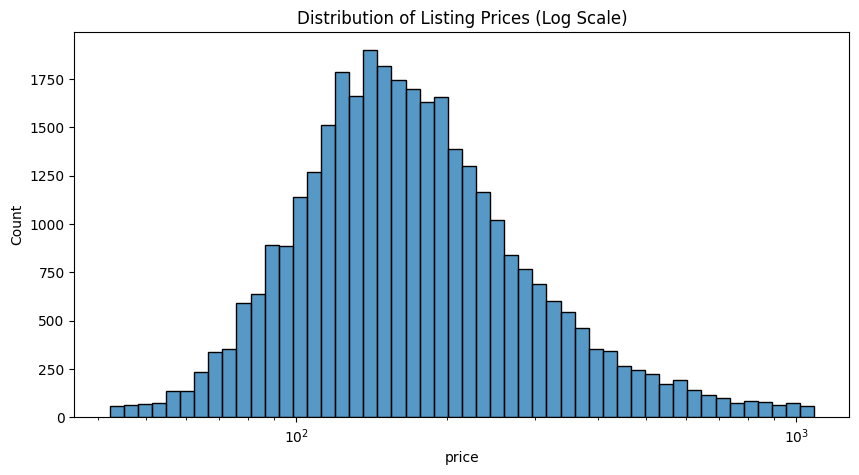

In [ ]:
plt.figure(figsize=(10,5))

# Usamos log_scale=True para el eje X
sns.histplot(final_df["price"], bins=50, log_scale=True)

plt.title("Distribution of Listing Prices (Log Scale)")
plt.show()

## 6. Final Dataset Validation

Before exporting the final dataset, we verify:

- dataset dimensions
- variable types
- remaining missing values

In [ ]:
print(final_df.shape)

(33636, 79)


In [ ]:
final_df.info()

<class 'pandas.DataFrame'>
Index: 33636 entries, 0 to 34323
Data columns (total 79 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   price                                              33636 non-null  float64
 1   latitude                                           33636 non-null  float64
 2   longitude                                          33636 non-null  float64
 3   accommodates                                       33636 non-null  int64  
 4   bedrooms                                           33636 non-null  float64
 5   beds                                               33636 non-null  float64
 6   bathrooms                                          33636 non-null  float64
 7   host_is_superhost                                  33636 non-null  int64  
 8   host_response_rate                                 0 non-null      float64
 9   host_acceptance_rate  

## 7. Export Final Dataset

The final integrated dataset is exported and will serve as the input for the machine learning models developed in Notebook 06.

In [ ]:
final_df.to_csv(
    "../data/final_dataset.csv",
    index=False
)

print("final_dataset.csv saved")
print(final_df.shape)

final_dataset.csv saved
(33636, 79)


In [ ]:
final_df.head()

,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,host_acceptance_rate,...,latest_review_day,days_since_latest_review,Seasonality_Index,month_sin,month_cos,season_Fall,season_Spring,season_Summer,season_Winter,season_no_reviews
0,59.52,41.87136,12.48215,1,1.0,1.0,1.5,0,NaN,NaN,...,8.0,4077.0,0.906591,5.000000e-01,-0.866025,False,True,False,False,False
1,117.13,41.92582,12.46928,3,2.0,3.0,1.0,1,NaN,NaN,...,1.0,339.0,0.650089,-8.660254e-01,-0.500000,False,False,True,False,False
2,160.60,41.90823,12.45293,5,2.0,3.0,1.0,0,NaN,NaN,...,13.0,23.0,0.899881,1.224647e-16,-1.000000,False,False,True,False,False
3,243.67,41.88992,12.46823,4,1.0,3.0,1.0,1,NaN,NaN,...,22.0,1322.0,0.390461,-5.000000e-01,0.866025,True,False,False,False,False
4,302.50,41.88992,12.46823,4,2.0,4.0,1.0,1,NaN,NaN,...,1.0,96.0,0.692730,8.660254e-01,-0.500000,False,True,False,False,False
